# Text Generation with Recurrent Neural Networks (RNNs)

In this assignment, you'll build upon your understanding of RNNs and Keras to develop a word-level text generation model.  Your goal is to train a model that learns the stylistic nuances of a chosen corpus and generates new, original text segments that echo the source material's essence.

**Datasets**

We've provided several intriguing text corpora to get you started:

*   Mark Twain
*   Charles Dickens
*   William Shakespeare

**Feel free to explore!**  If you have a particular passion for another author, genre, or a specific text, you're encouraged to use your own dataset of raw text.

In [48]:
# Check if we have a GPU available
import tensorflow as tf
if tf.test.gpu_device_name():
    print('Default GPU Device: {}'.format(tf.test.gpu_device_name()))
else:
    print("No GPU available. If you're on Colab, go to Runtime > Change runtime and select a GPU hardware accelerator.")

Default GPU Device: /device:GPU:0


In [49]:
import requests
import os

def download_file(book_name):
    base_url = "https://raw.githubusercontent.com/UofT-DSI/deep_learning/refs/heads/main/02_activities/assignments/downloaded_books/"
    file_url = base_url + book_name
    local_filename = book_name

    response = requests.get(file_url)
    if response.status_code == 200:
        with open(local_filename, 'w', encoding='utf-8') as f:
            f.write(response.text)
        print(f"Downloaded {book_name} successfully!")
        return local_filename
    else:
        raise ValueError("Failed to download the file. Please check the filename and try again.")

def load_dataset(file_path, fraction=1.0):
    with open(file_path, 'r', encoding='utf-8') as f:
        raw_text = f.read()
    return raw_text[:int(fraction * len(raw_text))]

# Prompt user to select a book
title_options = {
    "1": "charles_dickens.txt",
    "2": "mark_twain.txt",
    "3": "shakespeare.txt"
}

print("Choose a book to download:")
print("1: Charles Dickens")
print("2: Mark Twain")
print("3: William Shakespeare")

choice = None
while choice not in title_options:
    choice = input("Enter the number corresponding to your choice (1, 2, or 3): ").strip()
    if choice not in title_options:
        print("Invalid choice. Please enter 1, 2, or 3.")

selected_book = title_options[choice]
file_path = download_file(selected_book)

# Load chosen dataset
fraction = 0.1  # Adjust fraction if running out of memory
text = load_dataset(file_path, fraction=fraction)

print("Dataset loaded successfully!")

Choose a book to download:
1: Charles Dickens
2: Mark Twain
3: William Shakespeare
Enter the number corresponding to your choice (1, 2, or 3): 3
Downloaded shakespeare.txt successfully!
Dataset loaded successfully!


# 1. Data Preparation (Complete or Incomplete)

Before we can begin training an RNN model, we need to prepare the dataset. This involves cleaning the text, tokenizing words, and creating sequences the model can be trained on.

## 1.1 Data Exploration

Print the first 1000 characters of the dataset. Report the dataset's size and the number of unique characters it contains.

In [50]:
# Print the first 1000 characters
print("First 1000 characters:")
print(text[:1000])

# Report the dataset's size (in characters)
dataset_size = len(text)
print(f"\nDataset size: {dataset_size} characters")

# Report the number of unique characters
unique_characters = set(text)
print(f"Number of unique characters: {len(unique_characters)}")

First 1000 characters:
The Project Gutenberg EBook of Hamlet, by William Shakespeare

This eBook is for the use of anyone anywhere at no cost and with
almost no restrictions whatsoever.  You may copy it, give it away or
re-use it under the terms of the Project Gutenberg License included
with this eBook or online at www.gutenberg.org


Title: Hamlet

Author: William Shakespeare

Editor: Charles Kean

Release Date: January 10, 2009 [EBook #27761]

Language: English

Character set encoding: UTF-8

*** START OF THIS PROJECT GUTENBERG EBOOK HAMLET ***




Produced by David Starner, Curtis Weyant and the Online
Distributed Proofreading Team at https://www.pgdp.net









    Transcriber's Note:
    This is a heavily edited version of _Hamlet_. It was used
    for Charles Kean's 1859 stage production. Phrases printed
    in italics in the book are indicated in this electronic
    version by _ (underscore). Footnotes originally appeared
    at the bottom of each page. For this electronic ver

## 1.2 Text Pre-Processing

To prepare the dataset for training, we need to clean the text and create a numerical representation the model can interpret. Perform the following pre-processing steps:

*   Convert the entire text to lowercase.
*   Use the `Tokenizer` class from the `keras.preprocessing.text` module to tokenize the text. You should fit the tokenizer on the text and then convert the text to a sequence of numbers. You can use the `texts_to_sequences` method to do this.

**Note**:
* You'll need to specify an appropriate size for the vocabulary. The number of words in the list of most common words can serve as a guide - does it seem like a reasonable vocabulary size?
* Some of the words will be excluded from the vocabulary, as they don't appear often enough. It's important to provide a value for `oov_token` when creating the Tokenizer instance, so that these words can be represented as "unknown".

In [51]:
from tensorflow.keras.preprocessing.text import Tokenizer
import numpy as np
from sklearn.model_selection import train_test_split
import collections

VOCAB_SIZE = None
OOV_TOKEN = None

# 1. Convert the entire text to lowercase.
text_lower = text.lower()

# 2. Perform a basic tokenization by splitting on whitespace.
words = text_lower.split()

# 3. Count word frequencies using collections.Counter.
word_counts = collections.Counter(words)

# Display the 10 most common words.
print("Top 10 most common words:", word_counts.most_common(10))

# 4. Determine the candidate VOCAB_SIZE by covering 95% of the word occurrences.
#total_words = sum(word_counts.values())
#cumulative = 0
#vocab_size_candidate = 0
#threshold = 0.95  # Set to cover 95% of all word occurrences

#for word, count in word_counts.most_common():
#    cumulative += count
#    vocab_size_candidate += 1
#    if cumulative / total_words >= threshold:
#        break

#print(f"Candidate VOCAB_SIZE to cover {int(threshold * 100)}% of the word occurrences: {vocab_size_candidate}")

#VOCAB_SIZE = vocab_size_candidate
#print(f"Chosen VOCAB_SIZE: {VOCAB_SIZE}")
VOCAB_SIZE = 100
OOV_TOKEN = "<OOV>"

# 5. Create the Tokenizer instance with the specified vocabulary size and out-of-vocabulary token.
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)

# Fit the tokenizer on the lowercased text.
tokenizer.fit_on_texts([text_lower])

# 6. Convert the text to a sequence of numbers.
sequences = tokenizer.texts_to_sequences([text_lower])
# Since texts_to_sequences returns a list of sequences (one per text), we take the first element.
sequences = sequences[0]

# (Optional) Split the data into training and testing sets.
train_data, test_data = train_test_split(sequences, test_size=0.2, random_state=42)

# Display some details.
print("First 10 tokens of the sequence:", sequences[:10])
print("Vocabulary sample:", dict(list(tokenizer.word_index.items())[:10]))


Top 10 most common words: [('the', 6372), ('and', 4389), ('of', 3747), ('to', 3467), ('a', 2570), ('in', 2156), ('i', 1590), ('that', 1577), ('he', 1458), ('his', 1387)]
First 10 tokens of the sequence: [2, 56, 54, 1, 4, 1, 28, 1, 1, 20]
Vocabulary sample: {'<OOV>': 1, 'the': 2, 'and': 3, 'of': 4, 'to': 5, 'a': 6, 'in': 7, 'i': 8, 'that': 9, 'you': 10}


If everything worked, the following line should show you the first 10 words in the vocabulary:

In [52]:
print(list(tokenizer.word_index.items())[:10])

[('<OOV>', 1), ('the', 2), ('and', 3), ('of', 4), ('to', 5), ('a', 6), ('in', 7), ('i', 8), ('that', 9), ('you', 10)]


## 1.3 Sequence Generation

Now that the text has been tokenized, we need to create sequences the model can be trained on. There are two parts to this:

*   Use the `texts_to_sequences` method from the tokenizer to convert the text to a list of sequences of numbers.
*   Generate the training sequences. Each training sequence should contain `SEQ_LENGTH` token IDs from the text. The target token for each sequence should be the word that follows the sequence in the text.

In [53]:
SEQ_LENGTH = 50

# Convert the entire lowercased text into a list of token IDs
sequences = tokenizer.texts_to_sequences([text_lower])[0]

# Generate training sequences:
#   X: input sequences of SEQ_LENGTH tokens
#   y: the token immediately following each input sequence (target token)
X = []
y = []
for i in range(len(sequences) - SEQ_LENGTH):
    X.append(sequences[i: i + SEQ_LENGTH])
    y.append(sequences[i + SEQ_LENGTH])

# Convert lists to numpy arrays for model compatibility
X = np.array(X)
y = np.array(y)

# Drop examples where the target is the OOV token (if present)
if OOV_TOKEN in tokenizer.word_index:
    mask = y != tokenizer.word_index[OOV_TOKEN]
    X = X[mask]
    y = y[mask]

Assuming your sequences are stored in `X` and the corresponding targets in `y`, the following line should print the first training sequence and its target:

In [54]:
print(f'Sequence: {X[0]}\nTarget: {y[0]}')
print(f'Translated back to words: {[tokenizer.index_word[i] for i in X[0]]} -> {tokenizer.index_word[y[0]]}')

Sequence: [ 2 56 54  1  4  1 28  1  1 20  1 13 16  2  1  4  1  1 33 43  1  3 14  1
 43  1  1 10 85  1 15  1 15  1 29  1  1 15  1  2  1  4  2 56 54  1  1 14
 20  1]
Target: 29
Translated back to words: ['the', 'project', 'gutenberg', '<OOV>', 'of', '<OOV>', 'by', '<OOV>', '<OOV>', 'this', '<OOV>', 'is', 'for', 'the', '<OOV>', 'of', '<OOV>', '<OOV>', 'at', 'no', '<OOV>', 'and', 'with', '<OOV>', 'no', '<OOV>', '<OOV>', 'you', 'may', '<OOV>', 'it', '<OOV>', 'it', '<OOV>', 'or', '<OOV>', '<OOV>', 'it', '<OOV>', 'the', '<OOV>', 'of', 'the', 'project', 'gutenberg', '<OOV>', '<OOV>', 'with', 'this', '<OOV>'] -> or


And the following code will transform y into a one-hot encoded matrix, and split everything into training and validation sets:

In [55]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import numpy as np

# Convert X and y to numpy arrays
X = np.array(X)
y = np.array(y)

# One last thing: let's drop any examples where the target is the OOV token - we don't want our model to predict that (boring!)
mask = y != tokenizer.word_index[OOV_TOKEN]
X = X[mask]
y = y[mask]

# One-hot encode the target token
y = to_categorical(y, num_classes=VOCAB_SIZE)

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'X_train shape: {X_train.shape}')
print(f'y_train shape: {y_train.shape}')

X_train shape: (59444, 50)
y_train shape: (59444, 100)


# 2. Model Development (Complete or Incomplete)

With the dataset prepared, it's time to develop the RNN model. You'll need to define the architecture of the model, compile it, and prepare it for training.

## 2.1 Model Architecture

Define the architecture of your RNN model. You can design it however you like, but there are a few features that it's important to include:

*   An embedding layer that learns a dense representation of the input tokens. You'll need to specify the input dimension (the size of the vocabulary) and the output dimension (the size of the dense representation). Remember, you can look at the documentation [here](https://keras.io/api/layers/core_layers/embedding/).
*   At least one recurrent layer. We have learned how to use LSTM layers in class, but you can use other types of recurrent layers if you prefer. You can find the documentation [here](https://keras.io/api/layers/recurrent_layers/lstm/).
*   A dense layer with a softmax activation function. This layer will output a probability distribution over the vocabulary, so that the model can make predictions about the next token.

In [56]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model = Sequential([
    # Embedding layer:
    #   - input_dim: Set to VOCAB_SIZE, so each word index has a corresponding embedding.
    #   - output_dim: Size of the dense embedding vectors (here, 64 is chosen as an example).
    #   - input_length: Length of each input sequence (SEQ_LENGTH).
    Embedding(input_dim=VOCAB_SIZE, output_dim=64, input_length=SEQ_LENGTH),

    # LSTM layer:
    #   - 128 units: The number of LSTM cells, determining the size of the hidden state.
    #     This layer processes the embedded sequences and learns temporal dependencies.
    LSTM(128),

    # Dense output layer:
    #   - VOCAB_SIZE units: Each output corresponds to a word in the vocabulary.
    #   - Softmax activation: Converts the outputs into probabilities for each word,
    #     enabling the model to predict the next token in the sequence.
    Dense(VOCAB_SIZE, activation='softmax')
])

model.summary()


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)              │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_8 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 2.2 Model Compilation

Compile the model with an appropriate loss function and optimizer. You might also want to track additional metrics, such as accuracy.

Give a short explanation of your choice of loss function and optimizer:

Loss Function (categorical_crossentropy):
Since the model's output layer uses a softmax activation and the targets are one-hot encoded, categorical crossentropy is an appropriate choice. It measures the difference between the predicted probability distribution and the actual distribution.

Optimizer (adam):
Adam is widely used for its adaptive learning rate properties and efficiency in handling sparse gradients. It typically converges faster than other optimizers and works well out-of-the-box for many deep learning tasks.

Metrics (accuracy):
Tracking accuracy helps monitor how well the model is classifying the next word during training.

In [57]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy'])


## 2.3 Model Training

Train the model on the training data you've prepared.

* Train your model for 5 epochs with a batch size of 128. Use the validation data for validation.
* Store the training history in a variable called `history`.

In [58]:
# Train the model
history = model.fit(X_train, y_train,
                    epochs=5,
                    batch_size=128,
                    validation_data=(X_val, y_val))

#model.save('path/to/location.keras')
#model = keras.models.load_model('path/to/location.keras')

Epoch 1/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.0922 - loss: 4.1217 - val_accuracy: 0.1566 - val_loss: 3.7888
Epoch 2/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.1617 - loss: 3.6678 - val_accuracy: 0.1870 - val_loss: 3.4852
Epoch 3/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.1943 - loss: 3.4152 - val_accuracy: 0.1999 - val_loss: 3.3898
Epoch 4/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.2050 - loss: 3.3292 - val_accuracy: 0.2075 - val_loss: 3.3470
Epoch 5/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.2118 - loss: 3.2731 - val_accuracy: 0.2090 - val_loss: 3.3179


Plot the training history to visualize the model's learning progress. Your plot should include the training and validation loss.

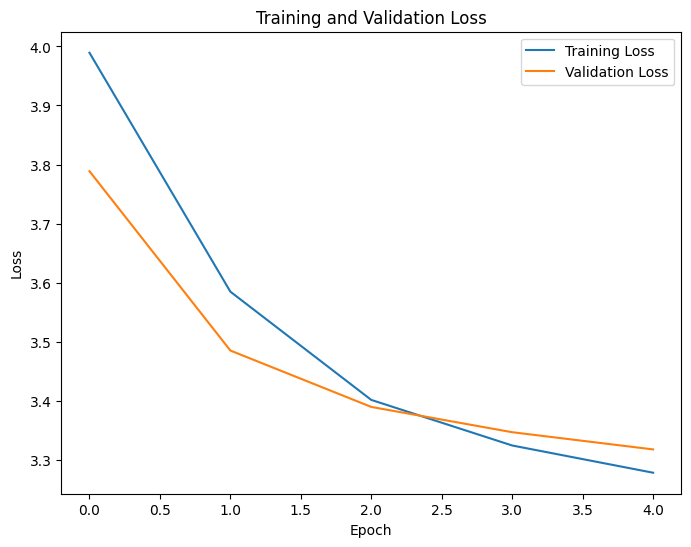

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

# 3. Text Generation (10 Marks)

## Task Overview

In this task, you will write a function called `generate_text` that uses a trained RNN model to generate new text based on a given seed phrase.

Your function **must** follow a structured approach to text generation, where the model predicts one word at a time, adds it to the sequence, and repeats this process until a desired length is reached.

## Function Requirements

You need to implement a function with the following signature:

```python
def generate_text(model, tokenizer, seed_text, max_sequence_len, n_words=100):
```

### **Parameters**
- `model`: The trained RNN model that will generate text.
- `tokenizer`: The tokenizer used to convert words to numerical sequences.
- `seed_text`: The initial text that will be used to start generating words.
- `max_sequence_len`: The maximum length of input sequences (same as used in training).
- `n_words` (optional, default=100): The number of words to generate.

### **Expected Output**
- A single **string** containing the generated text.

---

## **Step-by-Step Instructions**

### **1. Tokenize the seed text**
Use the tokenizer to convert `seed_text` into a sequence of numbers:

```python
encoded = tokenizer.texts_to_sequences([seed_text])[0]
```

### **2. Pad the sequence to match training input length**
Ensure that the sequence is the correct length by padding it **at the beginning**:

```python
from tensorflow.keras.preprocessing.sequence import pad_sequences
encoded = pad_sequences([encoded], maxlen=max_sequence_len, truncating='pre')
```

### **3. Predict the next word**
Pass the padded sequence to the model to predict the next word.

- The model will output a probability distribution over the vocabulary.
- Use `np.random.choice` or `np.argmax` to select the most likely word.

```python
yhat = model.predict(encoded, verbose=0)
predicted_word_index = np.argmax(yhat)  # Select the word with the highest probability
```

### **4. Convert the predicted word index to a word**
Find the corresponding word in the tokenizer’s vocabulary:

```python
out_word = tokenizer.index_word[predicted_word_index]
```

### **5. Append the new word to the generated text**
- Add the predicted word to `seed_text`.
- Repeat the process to generate multiple words.

```python
seed_text += " " + out_word
```

### **6. Repeat Steps 3-5 until `n_words` have been generated**

- Each time, remove the oldest word from the input sequence to keep its length constant.
- Continue generating words one at a time until reaching `n_words`.

---

## **Important Notes**
- If the generated text doesn’t make much sense, don’t worry! The quality will improve as the model is trained better.
- This is a **challenging** task! If you get stuck, ask for help.
- The `generate_text` function should return the **full generated text as a single string**.

### **Example Usage**
After implementing `generate_text`, you should be able to call it like this:

```python
generated_text = generate_text(model, tokenizer, "Once upon a time", max_sequence_len=20, n_words=50)
print(generated_text)
```

This should output a string of 50 words generated by the model, starting with `"Once upon a time"`.

In [62]:
def get_predicted_word(model, sequence):
    """
    Get the predicted word from the model.
    This helper function uses a bit of randomness
    so that the generated text can be more interesting.
    """
    # Use the model to predict the next token in the sequence
    yhat = model.predict(sequence, verbose=0)

    # Get the index of the predicted word, sampling according to the probabilities
    yhat = np.random.choice(range(VOCAB_SIZE), p=yhat.ravel())

    return yhat

def generate_text(model, tokenizer, seed_text, max_sequence_len, n_words=100):
    """
    Generate new text using the trained model.
    The function tokenizes the current text, pads it to max_sequence_len,
    predicts the next word using get_predicted_word, and appends it to the text.

    Parameters:
        model: The trained RNN model.
        tokenizer: The tokenizer for converting words to integers.
        seed_text: The initial text string to start the generation.
        max_sequence_len: The fixed input sequence length (same as used during training).
        n_words: The number of words to generate.

    Returns:
        A single string with the generated text.
    """
    generated_text = seed_text

    for _ in range(n_words):
        # Tokenize the current text and pad it to the desired length.
        encoded = tokenizer.texts_to_sequences([generated_text])[0]
        encoded = pad_sequences([encoded], maxlen=max_sequence_len, truncating='pre')

        # Get the predicted word index using the helper function.
        yhat = get_predicted_word(model, encoded)

        # Convert the predicted index back to a word.
        out_word = tokenizer.index_word.get(yhat, '')

        # If no valid word is found, exit the loop.
        if not out_word:
            break

        # Append the predicted word to the text.
        generated_text += " " + out_word

    return generated_text

# Train the model
history = model.fit(X_train, y_train,
                    epochs=5,
                    batch_size=128,
                    validation_data=(X_val, y_val))

Epoch 1/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.2482 - loss: 3.0457 - val_accuracy: 0.2247 - val_loss: 3.2271
Epoch 2/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.2512 - loss: 3.0300 - val_accuracy: 0.2253 - val_loss: 3.2191
Epoch 3/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.2606 - loss: 2.9909 - val_accuracy: 0.2290 - val_loss: 3.2158
Epoch 4/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.2674 - loss: 2.9529 - val_accuracy: 0.2323 - val_loss: 3.2042
Epoch 5/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.2696 - loss: 2.9487 - val_accuracy: 0.2308 - val_loss: 3.2113


In [63]:
# Test the text generation function
generated_text = generate_text(model, tokenizer, "Once upon a time", max_sequence_len=20, n_words=50)
print(generated_text)

Once upon a time as no a good work as they see the man in them it in the man our will would be upon and the king and to love were here and on the man man like a of her how he was a man had not to a man love his


# 4. Model Refinement (5 Marks)

## **Understanding Your Model's Performance**

At this stage, you might have noticed that the text generated by your model doesn’t make much sense yet. **This is completely expected!**

There are a few reasons why:
1. **RNNs have limitations** – While they can generate sequences, they struggle with long-range dependencies in text.
2. **Character-by-character generation is outdated** – Modern models like ChatGPT don’t generate text one letter at a time. Instead, they use **tokens**, which represent larger chunks of words, making their outputs much more coherent.
3. **Training time and data size** – Our model has been trained on a relatively small dataset for a short period of time, which means it hasn’t learned enough patterns to generate meaningful text.

Even though we don’t expect ChatGPT-level performance, this exercise is about **experimentation, not perfection**. Your goal here is to try **at least one** way to refine your model and observe how it affects the output.

---

## **Refining Your Model**
There are many ways to try improving your model. Here are some ideas:

✅ **Use pre-trained embeddings**  
   Instead of learning word representations from scratch, you can use pre-trained word embeddings. This allows your model to start with a better understanding of word relationships.

✅ **Modify the model architecture**  
   - Experiment with **more layers** or different numbers of units per layer.  
   - Try adding **dropout layers** to prevent overfitting.  
   - Consider using **bidirectional RNNs**, which process text in both forward and backward directions.  

✅ **Train for longer**  
   - Try increasing the number of **epochs** (but be mindful of overfitting).  
   - Experiment with different **batch sizes** to see if they affect training stability.  

Again, **perfection is NOT the goal here** – we just want to see that you experimented with improving your model! 🚀

In [64]:
!wget https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
!unzip glove.6B.zip

--2025-03-10 02:13:49--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip.2’

glove.6B.zip.2      100%[===================>] 822.24M  5.03MB/s    in 2m 39s  

2025-03-10 02:16:28 (5.18 MB/s) - ‘glove.6B.zip.2’ saved [862182613/862182613]

Archive:  glove.6B.zip
replace glove.6B.50d.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: glove.6B.50d.txt        
  inflating: glove.6B.100d.txt       
  inflating: glove.6B.200d.txt       
  inflating: glove.6B.300d.txt       


In [65]:
# Load the pre-trained embeddings
embeddings_index = {}
with open('glove.6B.100d.txt', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f'Found {len(embeddings_index)} word vectors.')

Found 400000 word vectors.


In [66]:
# Create an embedding matrix
embedding_matrix = np.zeros((VOCAB_SIZE, 100))
for word, i in tokenizer.word_index.items():
    if i < VOCAB_SIZE:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            embedding_matrix[i] = embedding_vector

In [67]:
embedding_layer = Embedding(
    VOCAB_SIZE, 100, weights=[embedding_matrix], trainable=False
)

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)              │ ?                           │          10,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_9 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,000 (39.06 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 10,000 (39.06 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)              │ ?                           │          10,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_9 (LSTM)                        │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 10,000 (39.06 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 10,000 (39.06 KB)

Epoch 1/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.2793 - loss: 2.9043 - val_accuracy: 0.2325 - val_loss: 3.2106
Epoch 2/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.2872 - loss: 2.8683 - val_accuracy: 0.2318 - val_loss: 3.2135
Epoch 3/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.2939 - loss: 2.8274 - val_accuracy: 0.2351 - val_loss: 3.2202
Epoch 4/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.3003 - loss: 2.7922 - val_accuracy: 0.2345 - val_loss: 3.2229
Epoch 5/5
465/465 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.3074 - loss: 2.7695 - val_accuracy: 0.2350 - val_loss: 3.2325


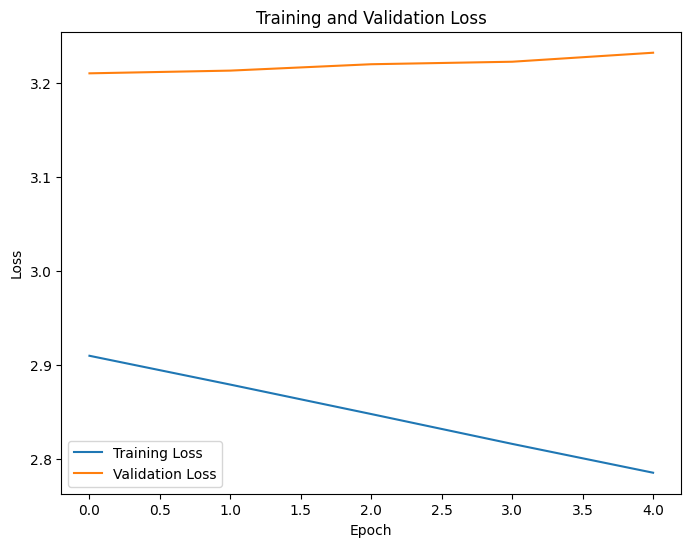

In [68]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
# Refining the model:
# - Increase embedding dimensions from 64 to 128.
# - Use two bidirectional LSTM layers.
# - Add dropout layers for regularization.

refined_model = Sequential([
    embedding_layer,
    LSTM(128),
    Dense(VOCAB_SIZE, activation='softmax')
])

refined_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
refined_model.summary()

# Compile the refined model using the same loss and optimizer.
history = refined_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy'])
refined_model.summary()

# Train the model
history = model.fit(X_train, y_train,
                    epochs=5,
                    batch_size=128,
                    validation_data=(X_val, y_val))

#model.save('path/to/location.keras')
#model = keras.models.load_model('path/to/location.keras')

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [69]:
# Test the text generation function
generate_text(model, tokenizer, 'hamlet', SEQ_LENGTH)

'hamlet what if she be like as this were like but his love these said she did man what then she will have it ” was his his there was as the king who had had said at that he was to with his work and by the king now his man who at the king had the king to the did and as he were now and no work as the one would have not have he had said work an man if he come for the which he did is and that he to be the king and when'

## Criteria

|Criteria|Complete|Incomplete|
|----|----|----|
|Task 1|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 2|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 3|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|
|Task 4|The task has been completed successfully and there are no errors.|The task is still incomplete and there is at least one error.|

## Submission Information

🚨**Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)**🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.

### Submission Parameters:
* Submission Due Date: `HH:MM AM/PM - DD/MM/YYYY`
* The branch name for your repo should be: `assignment-2`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_2.ipynb) should be populated and should be the only change in your pull request.
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
    * Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.

Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.

If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-3-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.